<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/Multi_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 1.2 MB/s eta 0:00:00


In [35]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
from IPython.display import Image

In [57]:
class SystemState(TypedDict):
    pass

def main(state: SystemState):
  print("Executing node MAIN")

def a(state: SystemState):
  print("Executing node A")

def b1(state: SystemState):
  print("Executing node B1")

def b2(state: SystemState):
  print("Executing node B2")

def finish(state: SystemState):
  print("Finished!")

In [81]:
checkpointer = InMemorySaver()

In [82]:
sub_graph_builder = StateGraph(SystemState)

sub_graph_builder.add_node("B1", b1)
sub_graph_builder.add_node("B2", b2)

sub_graph_builder.add_edge(START, "B1")
sub_graph_builder.add_edge("B1", "B2")
sub_graph_builder.add_edge("B2", END)

sub_graph = sub_graph_builder.compile() # Няма checkpointer, може ако го изполвам индивидуално, но когато искам да го съчетая, да е по-комплексно по-добре без допълнителни аргумента

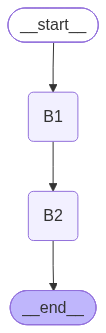

In [83]:
display(Image(data= sub_graph.get_graph().draw_mermaid_png(), format="png"))

In [84]:
graph_builder = StateGraph(SystemState)

graph_builder.add_node("Main", main)
graph_builder.add_node("A", a)
graph_builder.add_node("B", sub_graph)
graph_builder.add_node("Finish", finish)


graph_builder.add_edge(START, "Main")
graph_builder.add_edge("Main", "A")
graph_builder.add_edge("A", "Finish")

graph_builder.add_edge("Main", "B")
graph_builder.add_edge("B", 'Finish')

graph_builder.add_edge("Finish", END)

graph = graph_builder.compile(checkpointer)

b1 & b2 са събграф ще ги обединим и ще го представим като node на вътрешния

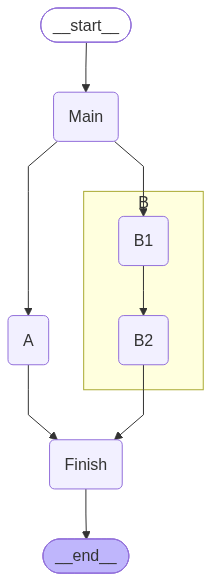

In [85]:
display(Image(data= graph.get_graph(xray=True).draw_mermaid_png(), format="png"))

In [86]:
thread1_config = { "configurable": {"thread_id": "t1"} }

graph.invoke(input={}, config = thread1_config)

Executing node MAIN
Executing node A
Executing node B1
Executing node B2
Finished!


In [88]:
list(checkpointer.list(thread1_config))

[CheckpointTuple(config={'configurable': {'thread_id': 't1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a932b-728f-6de5-8003-c086324662b1'}}, checkpoint={'v': 4, 'ts': '2026-09-05T14:04:31.157176+00:00', 'id': '1f1a932b-728f-6de5-8003-c086324662b1', 'channel_versions': {'__start__': '00000000000000000000000000000002.0.31203657991786193', 'branch:to:Main': '00000000000000000000000000000003.0.9285144612015781', 'branch:to:B': '00000000000000000000000000000004.0.11461370781246505', 'branch:to:A': '00000000000000000000000000000004.0.11461370781246505', 'branch:to:Finish': '00000000000000000000000000000005.0.9934425453849061'}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': '00000000000000000000000000000001.0.9549078323821696'}, 'Main': {'branch:to:Main': '00000000000000000000000000000002.0.31203657991786193'}, 'A': {'branch:to:A': '00000000000000000000000000000003.0.9285144612015781'}, 'B': {'branch:to:B': '00000000000000000000000000000003.0.9285144612015781'}, 'Finish': {'br

In [87]:
list(graph.get_state_history(thread1_config))

[StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': 't1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a932b-728f-6de5-8003-c086324662b1'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-09-05T14:04:31.157176+00:00', parent_config={'configurable': {'thread_id': 't1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a932b-728e-63ff-8002-a3f0de808296'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'branch:to:Finish': None}, next=('Finish',), config={'configurable': {'thread_id': 't1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a932b-728e-63ff-8002-a3f0de808296'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-05T14:04:31.156510+00:00', parent_config={'configurable': {'thread_id': 't1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a932b-7279-6d92-8001-a7af10b32db5'}}, tasks=(PregelTask(id='5f650a1e-c3ad-0592-9f2a-57188d07d8cd', name='Finish', path=('__pregel_pull', 'Finish'), error=None, interrupts=(), state=None, result={